# WARNING LIST ANALYSIS — OULAD & UCI 697

Notebook độc lập để đọc kết quả dự đoán từ notebook tuần 2, chia mức cảnh báo Low / Medium / High, tạo bảng tổng hợp và xuất danh sách CSV.

Mặc định:
- Low: Risk_Probability < 0.30
- Medium: 0.30 <= Risk_Probability < 0.60
- High: Risk_Probability >= 0.60

Lưu ý: các mức này dùng để phân tầng cảnh báo; không thay thế `DRS_Threshold` dùng cho dự đoán nhị phân At-risk / Non-risk.


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_DIR = "./week2_outputs/prediction_exports"
OUTPUT_DIR = "./warning_list_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

OULAD_FILE = os.path.join(INPUT_DIR, "oulad_predictions.csv")
UCI_FILE = os.path.join(INPUT_DIR, "uci697_predictions.csv")

LOW_THRESHOLD = 0.30
HIGH_THRESHOLD = 0.60

print("INPUT_DIR :", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


INPUT_DIR : ./week2_outputs/prediction_exports
OUTPUT_DIR: ./warning_list_outputs


In [6]:
if not os.path.exists(OULAD_FILE):
    raise FileNotFoundError(
        f"Không tìm thấy {OULAD_FILE}. Hãy chạy cell export OULAD ở cuối notebook tuần 2."
    )

if not os.path.exists(UCI_FILE):
    raise FileNotFoundError(
        f"Không tìm thấy {UCI_FILE}. Hãy chạy cell export UCI 697 ở cuối notebook tuần 2."
    )

oulad_pred = pd.read_csv(OULAD_FILE)
uci_pred = pd.read_csv(UCI_FILE)

print("OULAD:", oulad_pred.shape)
print("UCI 697:", uci_pred.shape)

display(oulad_pred.head())
display(uci_pred.head())


OULAD: (5578, 9)
UCI 697: (885, 20)


,id_student,code_module,code_presentation,student_key,final_result,Risk_Probability,DRS_Threshold,Predicted_At_Risk,Actual_At_Risk
0,28400,AAA,2013J,AAA_2013J_28400,Pass,0.172753,0.37,0,0
1,38053,AAA,2013J,AAA_2013J_38053,Pass,0.150754,0.37,0,0
2,45462,AAA,2013J,AAA_2013J_45462,Pass,0.202948,0.37,0,0
3,57506,AAA,2013J,AAA_2013J_57506,Pass,0.276080,0.37,0,0
4,59185,AAA,2013J,AAA_2013J_59185,Pass,0.444485,0.37,1,0


,Record_ID,Course,Application mode,Application order,Admission grade,Previous qualification (grade),Age at enrollment,Tuition fees up to date,Debtor,Scholarship holder,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Risk_Probability,DRS_Threshold,Predicted_At_Risk,Actual_At_Risk
0,UCI_02892,9670,1,2,135.9,131.0,18,1,0,1,0,6,6,6,13.166667,0,0.121362,0.55,0,0
1,UCI_02555,9119,1,1,150.8,163.0,18,1,0,0,0,5,9,4,10.500000,0,0.281406,0.55,0,0
2,UCI_02266,9003,7,1,140.0,140.0,50,1,0,0,2,6,8,2,13.500000,0,0.921928,0.55,1,1
3,UCI_03757,9500,1,2,124.6,137.0,18,1,0,0,0,7,10,7,13.398000,0,0.089246,0.55,0,0
4,UCI_03861,9773,18,1,153.0,167.0,18,1,0,1,0,6,6,1,11.000000,0,0.807662,0.55,1,1


In [7]:
COMMON_REQUIRED = [
    "Risk_Probability",
    "DRS_Threshold",
    "Predicted_At_Risk",
    "Actual_At_Risk"
]

def validate_prediction_file(df, name):
    missing = [c for c in COMMON_REQUIRED if c not in df.columns]
    if missing:
        raise ValueError(f"{name} thiếu cột: {missing}")
    if df["Risk_Probability"].isna().any():
        raise ValueError(f"{name} có Risk_Probability bị thiếu.")
    if not df["Risk_Probability"].between(0, 1).all():
        raise ValueError(f"{name}: Risk_Probability phải nằm trong [0, 1].")
    print(name, ": OK")

validate_prediction_file(oulad_pred, "OULAD")
validate_prediction_file(uci_pred, "UCI 697")


OULAD : OK
UCI 697 : OK


In [8]:
def assign_warning_level(p):
    if p < LOW_THRESHOLD:
        return "Low"
    elif p < HIGH_THRESHOLD:
        return "Medium"
    else:
        return "High"

def add_warning_columns(df):
    out = df.copy()
    out["Warning_Level"] = out["Risk_Probability"].apply(assign_warning_level)
    out["Predicted_Status"] = np.where(
        out["Predicted_At_Risk"] == 1,
        "At-risk",
        "Non-risk"
    )
    out["Actual_Status"] = np.where(
        out["Actual_At_Risk"] == 1,
        "At-risk",
        "Non-risk"
    )
    return out

oulad_warning = add_warning_columns(oulad_pred)
uci_warning = add_warning_columns(uci_pred)


In [9]:
WARNING_ORDER = {"High": 0, "Medium": 1, "Low": 2}

def sort_warning_list(df):
    out = df.copy()
    out["_warning_order"] = out["Warning_Level"].map(WARNING_ORDER)
    return (
        out.sort_values(
            ["_warning_order", "Risk_Probability"],
            ascending=[True, False]
        )
        .drop(columns="_warning_order")
        .reset_index(drop=True)
    )

oulad_warning = sort_warning_list(oulad_warning)
uci_warning = sort_warning_list(uci_warning)

display(oulad_warning.head(20))
display(uci_warning.head(20))


,id_student,code_module,code_presentation,student_key,final_result,Risk_Probability,DRS_Threshold,Predicted_At_Risk,Actual_At_Risk,Warning_Level,Predicted_Status,Actual_Status
0,2710343,DDD,2013B,DDD_2013B_2710343,Fail,0.938835,0.37,1,1,High,At-risk,At-risk
1,598666,CCC,2014B,CCC_2014B_598666,Withdrawn,0.938195,0.37,1,1,High,At-risk,At-risk
2,551137,FFF,2013B,FFF_2013B_551137,Withdrawn,0.937912,0.37,1,1,High,At-risk,At-risk
3,53197,FFF,2013B,FFF_2013B_53197,Fail,0.937823,0.37,1,1,High,At-risk,At-risk
4,577352,EEE,2013J,EEE_2013J_577352,Withdrawn,0.937714,0.37,1,1,High,At-risk,At-risk
5,521496,BBB,2013B,BBB_2013B_521496,Fail,0.937469,0.37,1,1,High,At-risk,At-risk
6,321142,BBB,2014B,BBB_2014B_321142,Fail,0.937137,0.37,1,1,High,At-risk,At-risk
7,2643777,DDD,2013B,DDD_2013B_2643777,Fail,0.937006,0.37,1,1,High,At-risk,At-risk
8,577170,BBB,2014B,BBB_2014B_577170,Fail,0.936957,0.37,1,1,High,At-risk,At-risk
9,529439,BBB,2014B,BBB_2014B_529439,Fail,0.936614,0.37,1,1,High,At-risk,At-risk


,Record_ID,Course,Application mode,Application order,Admission grade,Previous qualification (grade),Age at enrollment,Tuition fees up to date,Debtor,Scholarship holder,...,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Risk_Probability,DRS_Threshold,Predicted_At_Risk,Actual_At_Risk,Warning_Level,Predicted_Status,Actual_Status
0,UCI_02021,9853,39,1,128.2,140.0,30,0,0,0,...,0,0.0,0,0.971434,0.55,1,1,High,At-risk,At-risk
1,UCI_01381,9500,39,1,128.0,133.1,32,0,0,0,...,0,0.0,0,0.971338,0.55,1,1,High,At-risk,At-risk
2,UCI_03205,9991,39,1,111.0,133.1,28,0,0,0,...,0,0.0,0,0.971268,0.55,1,1,High,At-risk,At-risk
3,UCI_00035,33,39,1,102.5,130.0,37,0,1,0,...,0,0.0,0,0.971081,0.55,1,1,High,At-risk,At-risk
4,UCI_01747,9003,39,1,126.1,130.0,27,0,0,0,...,0,0.0,0,0.970749,0.55,1,1,High,At-risk,At-risk
5,UCI_01222,9991,39,1,121.7,133.1,31,0,1,0,...,0,0.0,0,0.970591,0.55,1,1,High,At-risk,At-risk
6,UCI_01386,9130,43,1,120.0,120.0,22,0,0,0,...,0,0.0,0,0.970407,0.55,1,1,High,At-risk,At-risk
7,UCI_03533,9254,39,1,120.0,133.1,45,0,1,0,...,0,0.0,0,0.970106,0.55,1,1,High,At-risk,At-risk
8,UCI_02748,9991,39,1,130.0,110.0,42,0,0,0,...,0,0.0,0,0.970062,0.55,1,1,High,At-risk,At-risk
9,UCI_02270,9991,7,1,140.0,140.0,33,0,0,0,...,0,0.0,0,0.970007,0.55,1,1,High,At-risk,At-risk


In [10]:
def show_warning_students(dataset, level="High", top_n=20):
    key = dataset.upper().replace(" ", "")
    level = level.capitalize()

    if level not in ["Low", "Medium", "High"]:
        raise ValueError("level phải là Low, Medium hoặc High.")

    if key == "OULAD":
        df = oulad_warning
        name = "OULAD"
    elif key in ["UCI", "UCI697"]:
        df = uci_warning
        name = "UCI 697"
    else:
        raise ValueError("dataset phải là OULAD hoặc UCI697.")

    subset = (
        df[df["Warning_Level"] == level]
        .sort_values("Risk_Probability", ascending=False)
    )

    print(f"{name} - {level} Risk")
    print("Số bản ghi:", len(subset))
    return subset.head(top_n)


In [11]:
show_warning_students("OULAD", "High", 20)


OULAD - High Risk
Số bản ghi: 1891


,id_student,code_module,code_presentation,student_key,final_result,Risk_Probability,DRS_Threshold,Predicted_At_Risk,Actual_At_Risk,Warning_Level,Predicted_Status,Actual_Status
0,2710343,DDD,2013B,DDD_2013B_2710343,Fail,0.938835,0.37,1,1,High,At-risk,At-risk
1,598666,CCC,2014B,CCC_2014B_598666,Withdrawn,0.938195,0.37,1,1,High,At-risk,At-risk
2,551137,FFF,2013B,FFF_2013B_551137,Withdrawn,0.937912,0.37,1,1,High,At-risk,At-risk
3,53197,FFF,2013B,FFF_2013B_53197,Fail,0.937823,0.37,1,1,High,At-risk,At-risk
4,577352,EEE,2013J,EEE_2013J_577352,Withdrawn,0.937714,0.37,1,1,High,At-risk,At-risk
5,521496,BBB,2013B,BBB_2013B_521496,Fail,0.937469,0.37,1,1,High,At-risk,At-risk
6,321142,BBB,2014B,BBB_2014B_321142,Fail,0.937137,0.37,1,1,High,At-risk,At-risk
7,2643777,DDD,2013B,DDD_2013B_2643777,Fail,0.937006,0.37,1,1,High,At-risk,At-risk
8,577170,BBB,2014B,BBB_2014B_577170,Fail,0.936957,0.37,1,1,High,At-risk,At-risk
9,529439,BBB,2014B,BBB_2014B_529439,Fail,0.936614,0.37,1,1,High,At-risk,At-risk


In [12]:
show_warning_students("UCI697", "High", 20)


UCI 697 - High Risk
Số bản ghi: 276


,Record_ID,Course,Application mode,Application order,Admission grade,Previous qualification (grade),Age at enrollment,Tuition fees up to date,Debtor,Scholarship holder,...,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Risk_Probability,DRS_Threshold,Predicted_At_Risk,Actual_At_Risk,Warning_Level,Predicted_Status,Actual_Status
0,UCI_02021,9853,39,1,128.2,140.0,30,0,0,0,...,0,0.0,0,0.971434,0.55,1,1,High,At-risk,At-risk
1,UCI_01381,9500,39,1,128.0,133.1,32,0,0,0,...,0,0.0,0,0.971338,0.55,1,1,High,At-risk,At-risk
2,UCI_03205,9991,39,1,111.0,133.1,28,0,0,0,...,0,0.0,0,0.971268,0.55,1,1,High,At-risk,At-risk
3,UCI_00035,33,39,1,102.5,130.0,37,0,1,0,...,0,0.0,0,0.971081,0.55,1,1,High,At-risk,At-risk
4,UCI_01747,9003,39,1,126.1,130.0,27,0,0,0,...,0,0.0,0,0.970749,0.55,1,1,High,At-risk,At-risk
5,UCI_01222,9991,39,1,121.7,133.1,31,0,1,0,...,0,0.0,0,0.970591,0.55,1,1,High,At-risk,At-risk
6,UCI_01386,9130,43,1,120.0,120.0,22,0,0,0,...,0,0.0,0,0.970407,0.55,1,1,High,At-risk,At-risk
7,UCI_03533,9254,39,1,120.0,133.1,45,0,1,0,...,0,0.0,0,0.970106,0.55,1,1,High,At-risk,At-risk
8,UCI_02748,9991,39,1,130.0,110.0,42,0,0,0,...,0,0.0,0,0.970062,0.55,1,1,High,At-risk,At-risk
9,UCI_02270,9991,7,1,140.0,140.0,33,0,0,0,...,0,0.0,0,0.970007,0.55,1,1,High,At-risk,At-risk


In [13]:
def warning_summary(dataset_name, df):
    counts = df["Warning_Level"].value_counts()
    return {
        "Dataset": dataset_name,
        "Low": int(counts.get("Low", 0)),
        "Medium": int(counts.get("Medium", 0)),
        "High": int(counts.get("High", 0)),
        "Total": int(len(df))
    }

warning_summary_table = pd.DataFrame([
    warning_summary("OULAD", oulad_warning),
    warning_summary("UCI 697", uci_warning)
])

display(warning_summary_table)


,Dataset,Low,Medium,High,Total
0,OULAD,1678,2009,1891,5578
1,UCI 697,499,110,276,885


In [14]:
warning_summary_percent = warning_summary_table.copy()

for level in ["Low", "Medium", "High"]:
    warning_summary_percent[level + " (%)"] = (
        warning_summary_percent[level]
        / warning_summary_percent["Total"]
        * 100
    ).round(2)

display(warning_summary_percent)


,Dataset,Low,Medium,High,Total,Low (%),Medium (%),High (%)
0,OULAD,1678,2009,1891,5578,30.08,36.02,33.90
1,UCI 697,499,110,276,885,56.38,12.43,31.19


In [15]:
def actual_risk_rate_by_level(df, dataset_name):
    rows = []
    for level in ["Low", "Medium", "High"]:
        subset = df[df["Warning_Level"] == level]
        rate = subset["Actual_At_Risk"].mean() if len(subset) else np.nan
        rows.append({
            "Dataset": dataset_name,
            "Warning_Level": level,
            "Count": len(subset),
            "Actual_At_Risk_Percent": round(rate * 100, 2) if pd.notna(rate) else np.nan
        })
    return pd.DataFrame(rows)

risk_rate_table = pd.concat([
    actual_risk_rate_by_level(oulad_warning, "OULAD"),
    actual_risk_rate_by_level(uci_warning, "UCI 697")
], ignore_index=True)

display(risk_rate_table)


,Dataset,Warning_Level,Count,Actual_At_Risk_Percent
0,OULAD,Low,1678,18.71
1,OULAD,Medium,2009,39.12
2,OULAD,High,1891,71.55
3,UCI 697,Low,499,7.41
4,UCI 697,Medium,110,26.36
5,UCI 697,High,276,78.99


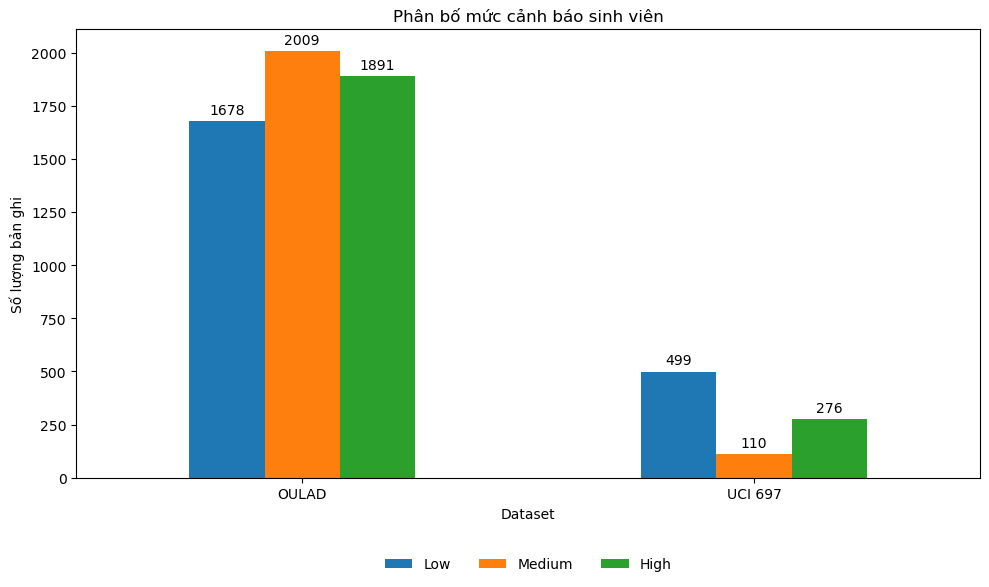

Đã lưu: ./warning_list_outputs\warning_level_distribution.png


In [16]:
plot_df = (
    warning_summary_table
    .set_index("Dataset")[["Low", "Medium", "High"]]
)

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Phân bố mức cảnh báo sinh viên")
ax.set_xlabel("Dataset")
ax.set_ylabel("Số lượng bản ghi")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.tight_layout()

chart_path = os.path.join(
    OUTPUT_DIR,
    "warning_level_distribution.png"
)

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", chart_path)


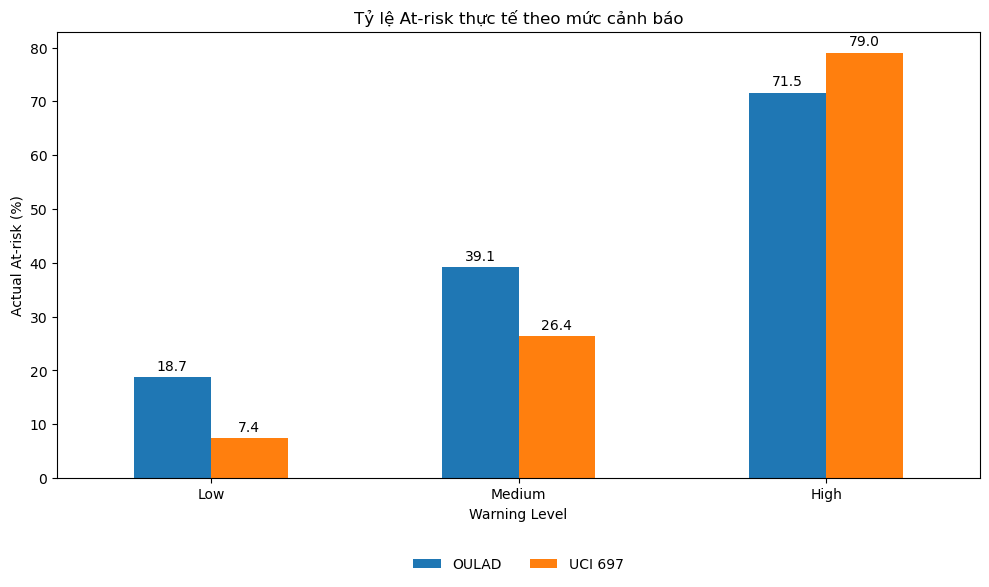

Đã lưu: ./warning_list_outputs\actual_risk_rate_by_warning_level.png


In [17]:
plot_rate = (
    risk_rate_table
    .pivot(
        index="Warning_Level",
        columns="Dataset",
        values="Actual_At_Risk_Percent"
    )
    .reindex(["Low", "Medium", "High"])
)

ax = plot_rate.plot(kind="bar", figsize=(10, 6))
ax.set_title("Tỷ lệ At-risk thực tế theo mức cảnh báo")
ax.set_xlabel("Warning Level")
ax.set_ylabel("Actual At-risk (%)")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()

risk_chart_path = os.path.join(
    OUTPUT_DIR,
    "actual_risk_rate_by_warning_level.png"
)

plt.savefig(risk_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", risk_chart_path)


In [18]:
oulad_warning.to_csv(
    os.path.join(OUTPUT_DIR, "oulad_warning_list.csv"),
    index=False
)

uci_warning.to_csv(
    os.path.join(OUTPUT_DIR, "uci697_warning_list.csv"),
    index=False
)

warning_summary_table.to_csv(
    os.path.join(OUTPUT_DIR, "warning_level_summary.csv"),
    index=False
)

warning_summary_percent.to_csv(
    os.path.join(OUTPUT_DIR, "warning_level_summary_percent.csv"),
    index=False
)

risk_rate_table.to_csv(
    os.path.join(OUTPUT_DIR, "actual_risk_rate_by_warning_level.csv"),
    index=False
)

for level in ["Low", "Medium", "High"]:
    oulad_warning[
        oulad_warning["Warning_Level"] == level
    ].to_csv(
        os.path.join(OUTPUT_DIR, f"oulad_{level.lower()}_risk.csv"),
        index=False
    )

    uci_warning[
        uci_warning["Warning_Level"] == level
    ].to_csv(
        os.path.join(OUTPUT_DIR, f"uci697_{level.lower()}_risk.csv"),
        index=False
    )

print("Đã export warning lists.")


Đã export warning lists.


In [19]:
print("WARNING LIST OUTPUTS")
print("=" * 60)

for name in sorted(os.listdir(OUTPUT_DIR)):
    print("-", name)


WARNING LIST OUTPUTS
- actual_risk_rate_by_warning_level.csv
- actual_risk_rate_by_warning_level.png
- oulad_high_risk.csv
- oulad_low_risk.csv
- oulad_medium_risk.csv
- oulad_warning_list.csv
- uci697_high_risk.csv
- uci697_low_risk.csv
- uci697_medium_risk.csv
- uci697_warning_list.csv
- warning_level_distribution.png
- warning_level_summary.csv
- warning_level_summary_percent.csv
